<a href="https://colab.research.google.com/github/vohoangloc-32/vibe_network/blob/a_branch/vibe_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[cols].copy()
y = df['Survived']

X['Sex'] = X['Sex'].map({'male': 0, 'female': 1})
X['Age'] = X['Age'].fillna(X['Age'].mean())

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)

In [41]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[6]),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [42]:
early_stopping = keras.callbacks.EarlyStopping(
    patience=10,
    min_delta=0.001,
    restore_best_weights=True,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=32,
    epochs=100,
    callbacks=[early_stopping],
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - binary_accuracy: 0.6643 - loss: 0.6534 - val_binary_accuracy: 0.7709 - val_loss: 0.5870
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - binary_accuracy: 0.7683 - loss: 0.5489 - val_binary_accuracy: 0.8045 - val_loss: 0.5564
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - binary_accuracy: 0.7781 - loss: 0.5168 - val_binary_accuracy: 0.8101 - val_loss: 0.5421
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.7879 - loss: 0.4821 - val_binary_accuracy: 0.8212 - val_loss: 0.5128
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7697 - loss: 0.5157 - val_binary_accuracy: 0.8045 - val_loss: 0.5005
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.7921 - loss: 0.4723 - val_binary_accuracy: 0.8101 - val_loss: 0.4808
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - binary_accuracy: 0.7935 - loss: 0.4926 - val_binary_accuracy: 0.8101 - val_loss: 0.4719
Epoch 8/100


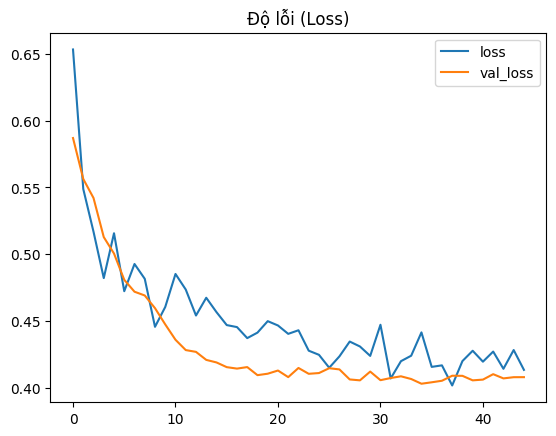

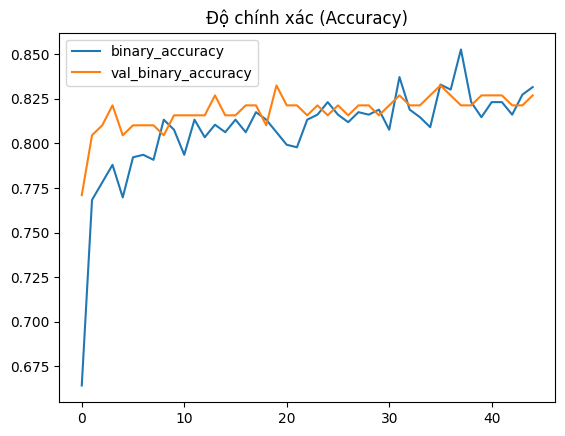

In [43]:
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot(title="Độ lỗi (Loss)")
history_df.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot(title="Độ chính xác (Accuracy)")
plt.show()

In [31]:

my_data = {
    'Pclass': 1,
    'Sex': 0,
    'Age': 19,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 100.0
}

df_me = pd.DataFrame([my_data])

In [44]:

me_scaled = scaler.transform(df_me)

prediction = model.predict(me_scaled)

print(f"--- KẾT QUẢ DỰ ĐOÁN CHO LỘC ---")
print(f"Xác suất sống sót: {prediction[0][0] * 100:.2f}%")

if prediction[0][0] > 0.5:
    print("Trạng thái: CHÚC MỪNG, BẠN CÓ KHẢ NĂNG SỐNG SÓT!")
else:
    print("Trạng thái: CÓ VẺ BẠN NÊN TÌM CÁI PHAO GẤP...")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step
--- KẾT QUẢ DỰ ĐOÁN CHO LỘC ---
Xác suất sống sót: 32.27%
Trạng thái: CÓ VẺ BẠN NÊN TÌM CÁI PHAO GẤP...
